# Optimizing k-NN Classification with PCA and Hyperparameter Tuning

This notebook builds an optimized k-Nearest Neighbors classifier for the wine dataset by:

1. Converting categorical target labels into numeric values
2. Applying PCA to reduce dimensionality while retaining 95% variance
3. Using `GridSearchCV` to find the optimal k-value and distance metric
4. Training the k-NN classifier using the best parameters
5. Evaluating the model with a classification report and accuracy score

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

## Load the Data

In [2]:
df = pd.read_csv('wine.csv')
print(df.shape)
df.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Step 1: Convert Categorical Target Labels into Numeric Values

The `target` column identifies which of three wine cultivars each sample belongs to. We first map it to its descriptive class names, then use `LabelEncoder` to convert those categorical labels into the numeric values the classifier needs. `LabelEncoder` also gives us a clean, reusable mapping back to the original class names for reporting results later.

In [3]:
# Map the raw target codes to descriptive categorical class names
class_name_map = {0: 'class_0', 1: 'class_1', 2: 'class_2'}
df['target_label'] = df['target'].map(class_name_map)

print(df['target_label'].value_counts())
df[['target', 'target_label']].head()

target_label
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,target,target_label
0,0,class_0
1,0,class_0
2,0,class_0
3,0,class_0
4,0,class_0


In [4]:
# Encode the categorical labels into numeric values
label_encoder = LabelEncoder()
df['target_encoded'] = label_encoder.fit_transform(df['target_label'])

print("Classes:", list(label_encoder.classes_))
print("Encoded mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

df[['target_label', 'target_encoded']].drop_duplicates().sort_values('target_encoded')

Classes: ['class_0', 'class_1', 'class_2']
Encoded mapping: {'class_0': np.int64(0), 'class_1': np.int64(1), 'class_2': np.int64(2)}


,target_label,target_encoded
0,class_0,0
59,class_1,1
130,class_2,2


## Prepare Features and Target, Train/Test Split

We split the data before scaling and PCA so both are fit only on the training set, avoiding any leakage of test-set information.

In [5]:
feature_cols = [c for c in df.columns if c not in ('target', 'target_label', 'target_encoded')]
X = df[feature_cols]
y = df['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 133 samples, 13 features
Test set:     45 samples


### Scale the Features

k-NN and PCA are both distance/variance-based methods, so features must be standardized first (raw features here range from `hue` around 1 to `proline` in the hundreds).

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 2: Apply PCA to Retain 95% Variance

We fit PCA on the training data with `n_components=0.95`, which tells scikit-learn to automatically keep the minimum number of components needed to explain at least 95% of the variance.

In [7]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of PCA components retained: {pca.n_components_}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Variance per component: {np.round(pca.explained_variance_ratio_, 3)}")

Original number of features: 13
Number of PCA components retained: 10
Total variance retained: 0.9637
Variance per component: [0.357 0.192 0.108 0.074 0.069 0.052 0.044 0.025 0.022 0.019]


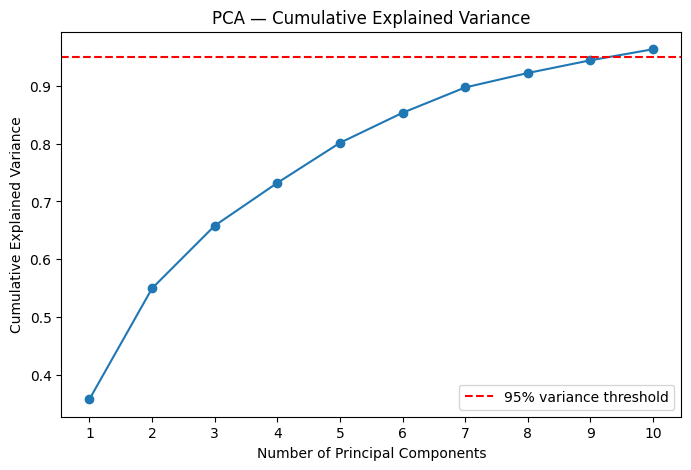

In [8]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_var) + 1))
plt.legend()
plt.show()

## Step 3: Use GridSearchCV to Find the Optimal k and Distance Metric

We search over:
- `n_neighbors`: the number of neighbors (k), from 1 to 20
- `weights`: uniform vs. distance-weighted voting
- `p`: the Minkowski distance parameter (1 = Manhattan, 2 = Euclidean)

All combinations are evaluated with 5-fold cross-validation on the PCA-transformed training data, scored on accuracy.

In [9]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'n_neighbors': 13, 'p': 1, 'weights': 'uniform'}
Best cross-validated accuracy: 0.9772


### Visualizing accuracy across k values

Using the best `weights` and `p` found above, we look at how cross-validated accuracy changes with k.

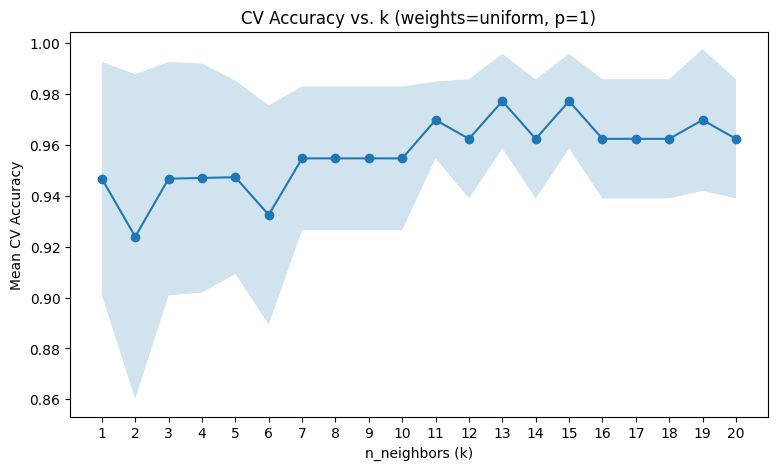

In [10]:
results = pd.DataFrame(grid_search.cv_results_)

best_weights = grid_search.best_params_['weights']
best_p = grid_search.best_params_['p']

subset = results[
    (results['param_weights'] == best_weights) &
    (results['param_p'] == best_p)
].sort_values('param_n_neighbors')

plt.figure(figsize=(9, 5))
plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o')
plt.fill_between(
    subset['param_n_neighbors'],
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2
)
plt.xlabel('n_neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.title(f'CV Accuracy vs. k (weights={best_weights}, p={best_p})')
plt.xticks(subset['param_n_neighbors'])
plt.show()

## Step 4: Train the k-NN Classifier Using the Best Parameters

`GridSearchCV` already refits a model with the best parameters on the full training set (`grid_search.best_estimator_`), but for clarity we also build the classifier explicitly using `grid_search.best_params_`.

In [11]:
best_knn = KNeighborsClassifier(**grid_search.best_params_)
best_knn.fit(X_train_pca, y_train)

print("Final model:", best_knn)

Final model: KNeighborsClassifier(n_neighbors=13, p=1)


## Step 5: Evaluate the Model

We generate predictions on the held-out (never-before-seen) PCA-transformed test set and evaluate with a classification report and accuracy score.

In [12]:
y_pred = best_knn.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.4f}\n")

target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names))

Test set accuracy: 0.9778

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



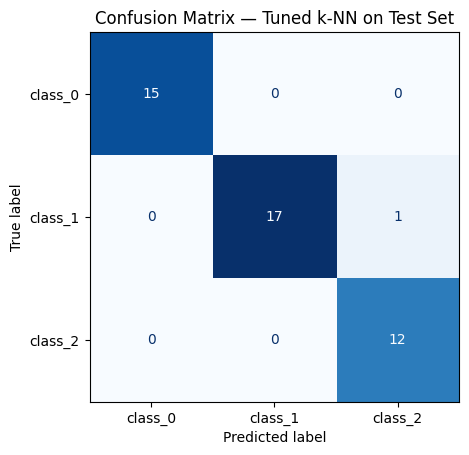

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned k-NN on Test Set')
plt.show()

## Summary

- **Target encoding:** categorical class labels (`class_0`, `class_1`, `class_2`) were converted to numeric values with `LabelEncoder`.
- **PCA:** dimensionality was reduced from 13 features down to the fewest components needed to retain 95% of the variance (see output above for the exact count).
- **Tuning:** `GridSearchCV` searched `n_neighbors` (1–20), `weights`, and `p` (distance metric) with 5-fold cross-validation to find the best combination.
- **Final model:** trained on the PCA-reduced training data using the best parameters found, then evaluated on the untouched test set with accuracy and a full classification report.

If test accuracy diverges noticeably from the cross-validated training accuracy, that's worth watching — with a modest sample size, results can shift somewhat depending on the train/test split and random seed. The cross-validated score is generally the more stable number for comparing configurations.